<a href="https://colab.research.google.com/github/tharindu9216/Accident-Severity-Classifier-/blob/Logistic_Regression/Logistic_Regestion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression — Road Accident Severity Prediction

---

## 1. Dataset Selection & Justification

**Dataset:** Road Accident Casualties Dataset
**Source:** https://www.kaggle.com/datasets/nezukokamaado/road-accident-casualties-dataset
**Author:** nezukokamaado on Kaggle

### Why this dataset is appropriate

This dataset was selected because it satisfies all required criteria for a supervised machine learning assignment:

- **Real-world, non-tutorial data:** The dataset contains genuine UK road accident records collected by the Department for Transport. It is not associated with any textbook example or ML tutorial.
- **Complexity:** With 307,973 records and 21 features spanning categorical, numerical, and temporal attributes, the dataset presents realistic challenges including class imbalance, missing values, and heterogeneous feature types.
- **Publicly hosted:** The dataset is permanently hosted on Kaggle with a citable URL, satisfying the requirement that data be accessible online.

### Dataset description

| Property | Detail |
|---|---|
| Records | 307,973 road accidents |
| Features | 21 columns (17 categorical, 4 numerical) |
| Target variable | `Accident_Severity` — Fatal / Serious / Slight |
| Year coverage | 2021 (UK national data) |
| Class distribution | ~85% Slight, ~14% Serious, ~1% Fatal (imbalanced) |
| Missing values | Present in `Carriageway_Hazards`, `Junction_Control` |

**Key features include:** Day of week, road type, speed limit, light conditions, weather conditions, road surface conditions, urban/rural classification, vehicle type, junction control, and number of casualties/vehicles.

**Prediction task:** Multi-class classification — given the conditions of a road accident, predict whether the outcome is *Fatal*, *Serious*, or *Slight*. This is a high-value real-world problem: accurate severity prediction can inform emergency response prioritisation and road safety policy.

---

## 2. Algorithm Selection & Justification

**Algorithm:** Logistic Regression (Multinomial, with L1/L2 Regularisation)

### Why Logistic Regression

| Criterion | Justification |
|---|---|
| Probabilistic output | Logistic Regression produces calibrated class probabilities — P(Fatal), P(Serious), P(Slight) — making predictions interpretable and directly usable for risk scoring in road safety applications. |
| Strong baseline | Logistic Regression is the standard benchmark for multi-class classification. Its performance establishes a meaningful lower bound against which more complex models (Random Forest, SVM, Neural Networks) can be fairly compared. |
| Handles high-dimensional sparse data | After One-Hot Encoding, the feature space becomes large and sparse. Logistic Regression with L1 regularisation performs implicit feature selection by shrinking irrelevant coefficients to zero, making it well-suited to this structure. |
| Regularisation controls overfitting | The hyperparameter C (inverse regularisation strength) is tuned via GridSearchCV. Smaller C values apply stronger regularisation, preventing the model from overfitting to SMOTE-generated synthetic samples. |
| Coefficient interpretability | Each feature has a directly readable coefficient per class. This makes it straightforward to explain *why* the model predicted a given severity — a significant advantage in safety-critical domains. |
| Efficiency | Logistic Regression trains orders of magnitude faster than ensemble or deep methods, making it practical to run full GridSearchCV over 16 hyperparameter combinations on a large dataset. |

### Algorithm background

Logistic Regression models the probability of each class using the **softmax function** for multi-class problems (multinomial logistic regression). For a feature vector **x**, the probability of class *k* is:

$$P(y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k \cdot \mathbf{x}}}{\sum_{j} e^{\mathbf{w}_j \cdot \mathbf{x}}}$$

The model is trained by minimising the **cross-entropy loss** with an added regularisation term. Two penalty types are evaluated:

- **L2 (Ridge):** Shrinks all coefficients toward zero — reduces variance without eliminating features.
- **L1 (Lasso):** Drives irrelevant coefficients to exactly zero — performs automatic feature selection, beneficial given the large One-Hot-Encoded feature space.

**Implementation choices in this work:**
- `StandardScaler` applied to numerical features — essential for Logistic Regression, as unscaled features with large magnitudes (e.g., speed limit = 70) would dominate features with small magnitudes (e.g., `High_Speed` = 0 or 1).
- SMOTE applied after scaling to address the severe class imbalance (~1% Fatal).
- `class_weight='balanced'` set as an additional safeguard within the model itself.
- Solvers `liblinear` and `saga` evaluated — both support L1 and L2; `saga` scales better on large datasets.

**References:**
Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.
Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. **bold text**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install gdown (run once)
!pip install gdown -q

import gdown

# Your file ID
file_id = "1vZ7-UTWWXcVPcEvgkUBDHv715S4co-vC"

# Download file
gdown.download(f"https://drive.google.com/uc?id={file_id}", "my_file.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1vZ7-UTWWXcVPcEvgkUBDHv715S4co-vC
To: /content/my_file.csv
100%|██████████| 69.0M/69.0M [00:01<00:00, 53.4MB/s]


'my_file.csv'

In [3]:
# To Check Data Was Successfully Downloaded
import pandas as pd

# Load the CSV file (FIXED NAME)
df = pd.read_csv("my_file.csv")

# Display the first 5 rows
print(df.head())

  Accident_Index Accident Date Day_of_Week          Junction_Control  \
0      BS0000001      1/1/2021    Thursday  Give way or uncontrolled   
1      BS0000002      5/1/2021      Monday  Give way or uncontrolled   
2      BS0000003      4/1/2021      Sunday  Give way or uncontrolled   
3      BS0000004      5/1/2021      Monday       Auto traffic signal   
4      BS0000005      6/1/2021     Tuesday       Auto traffic signal   

           Junction_Detail Accident_Severity   Latitude  \
0  T or staggered junction           Serious  51.512273   
1               Crossroads           Serious  51.514399   
2  T or staggered junction            Slight  51.486668   
3  T or staggered junction           Serious  51.507804   
4               Crossroads           Serious  51.482076   

        Light_Conditions Local_Authority_(District) Carriageway_Hazards  ...  \
0               Daylight     Kensington and Chelsea                 NaN  ...   
1               Daylight     Kensington and Chelsea 

In [4]:
# Load & Inspect the Data
import pandas as pd
import numpy as np

# FIXED FILE NAME
df = pd.read_csv('my_file.csv')

print(df.shape)           # (rows, columns)
print(df.dtypes)          # column types
print(df.isnull().sum())  # missing values
print(df['Accident_Severity'].value_counts())  # class distribution

(307973, 21)
Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object
Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail            

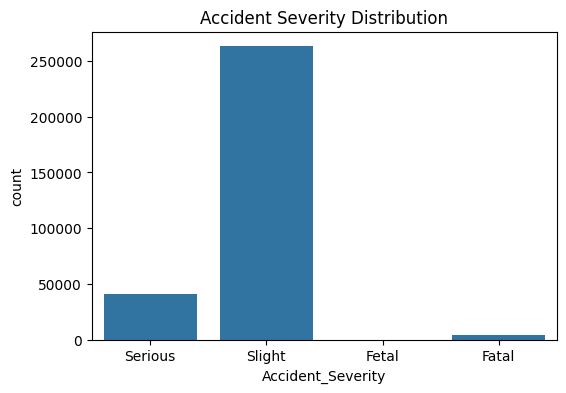

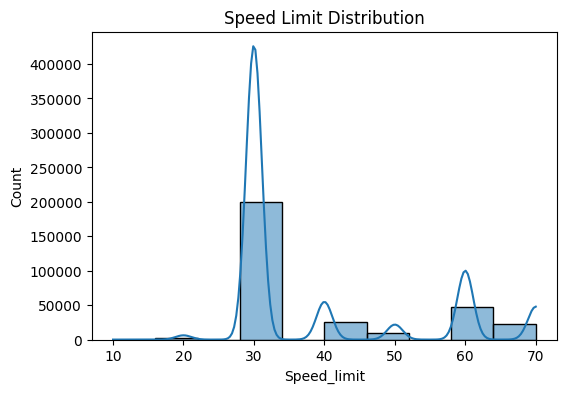

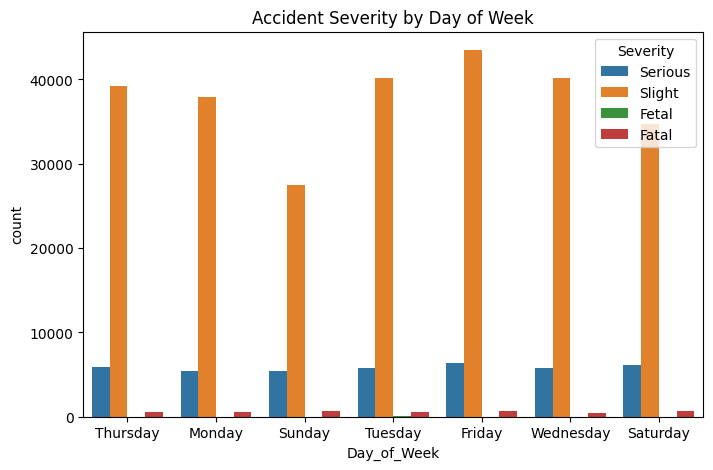

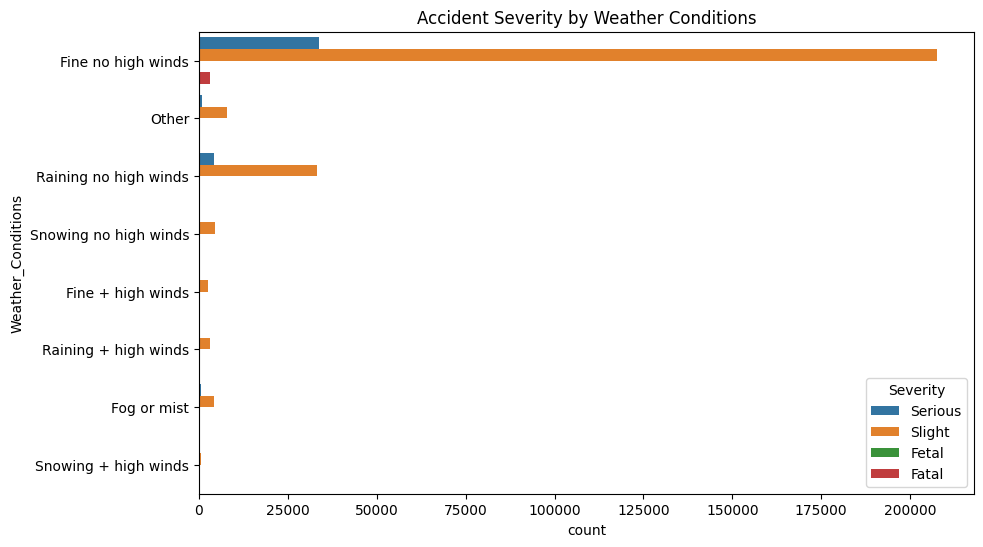

In [5]:
# plots and charts for data-set

import matplotlib.pyplot as plt
import seaborn as sns

# Accident Severity Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()
print()

# Speed Limit Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Speed_limit'], bins=10, kde=True)
plt.title("Speed Limit Distribution")
plt.show()
print()

# Day of Week vs Severity
plt.figure(figsize=(8,5))
sns.countplot(x='Day_of_Week', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Day of Week")
plt.legend(title="Severity")
plt.show()
print()

# Weather Conditions vs Severity
plt.figure(figsize=(10,6))
sns.countplot(y='Weather_Conditions', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Weather Conditions")
plt.legend(title="Severity")
plt.show()

In [6]:
# Drop Irrelevant Columns
df = df.drop(columns=['Accident_Index', 'Latitude', 'Longitude',
                       'Local_Authority_(District)', 'Police_Force'])

In [7]:
# Fix 'Fetal' Typo — Merge into 'Fatal'
df['Accident_Severity'] = df['Accident_Severity'].str.strip()
df['Accident_Severity'] = df['Accident_Severity'].replace('Fetal', 'Fatal')

print('Unique values after fix:', sorted(df['Accident_Severity'].unique()))
print('Class counts:', df['Accident_Severity'].value_counts())
print(f'Total records: {len(df):,}  (no rows dropped)')

Unique values after fix: ['Fatal', 'Serious', 'Slight']
Class counts: Accident_Severity
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64
Total records: 307,973  (no rows dropped)


In [8]:
# Feature Engineering
df['High_Speed'] = (df['Speed_limit'] >= 60).astype(int)

In [9]:
# Separate Features (X) and Target (y)
# Define the target column
TARGET = 'Accident_Severity'

# Columns to drop from features
DROP_COLS = ['Accident_Index', 'Accident Date', 'Latitude', 'Longitude',
             'Local_Authority_(District)', 'Police_Force', 'Time']

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET]
print('Feature shape:', X.shape)

Feature shape: (307973, 14)


In [10]:
# Train/Test Split (80/20, stratified)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # reproducibility seed
    stratify=y           # keep class proportions in both splits
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (246378, 14) | Test: (61595, 14)


In [11]:
# Build Preprocessing Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Pipeline for categorical columns
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Pipeline for numerical columns (tree model version — NO scaling)
num_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# ColumnTransformer applies each pipeline to the right columns
preproc_tree = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe_tree, num_cols)
])

# FIT on training data ONLY — then transform both train and test
preproc_tree.fit(X_train)
Xtr_tree = preproc_tree.transform(X_train)
Xte_tree = preproc_tree.transform(X_test)

# Convert sparse matrix to dense for SMOTE compatibility
Xtr_tree_dense = Xtr_tree.toarray() if hasattr(Xtr_tree, 'toarray') else Xtr_tree
Xte_tree_dense = Xte_tree.toarray() if hasattr(Xte_tree, 'toarray') else Xte_tree


In [12]:
# Handle Class Imbalance with SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Before SMOTE:', Counter(y_train))

sm = SMOTE(random_state=42)
Xtr_res, ytr_res = sm.fit_resample(Xtr_tree_dense, y_train)

print('After SMOTE:', Counter(ytr_res))



Before SMOTE: Counter({'Slight': 210624, 'Serious': 32592, 'Fatal': 3162})
After SMOTE: Counter({'Slight': 210624, 'Fatal': 210624, 'Serious': 210624})


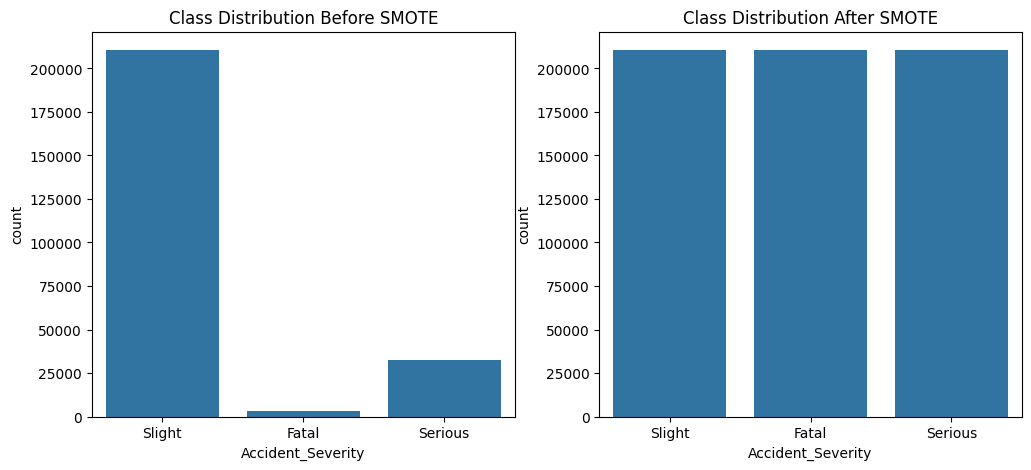

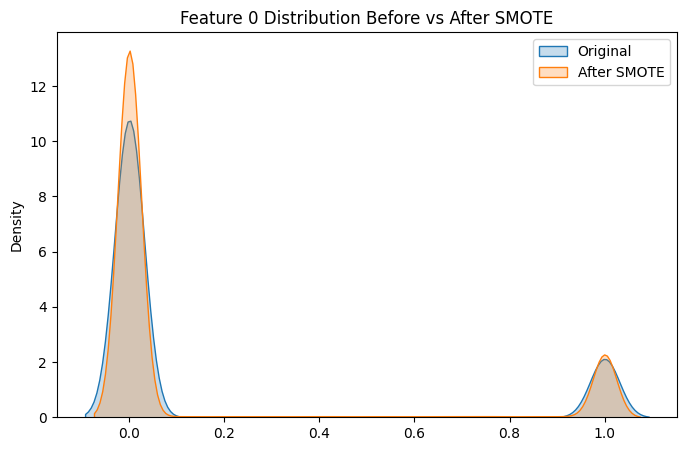

In [13]:
# Plots for handling imbalance before and after.
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plot class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Class Distribution Before SMOTE")

# After SMOTE
sns.countplot(x=ytr_res, ax=axes[1])
axes[1].set_title("Class Distribution After SMOTE")

plt.show()
print()

# Optional: Compare feature distributions before vs after SMOTE
feature = 0  # pick a feature index (e.g., 0 for first column)
plt.figure(figsize=(8,5))
sns.kdeplot(Xtr_tree_dense[:, feature], label="Original", fill=True)
sns.kdeplot(Xtr_res[:, feature], label="After SMOTE", fill=True)
plt.title(f"Feature {feature} Distribution Before vs After SMOTE")
plt.legend()
plt.show()

# Add StandardScaler for Logistic Regression

In [14]:
# Logistic Regression requires feature scaling unlike tree-based models
# We build a separate preprocessor that includes StandardScaler for numerical columns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Pipeline for categorical columns (same as before)
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing with most common value
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))  # convert to 0/1 columns
])

# Pipeline for numerical columns — WITH StandardScaler (required for Logistic Regression)
# StandardScaler transforms each feature to mean=0 and std=1
# Without this, features with large values (e.g. speed=70) dominate over small ones (e.g. High_Speed=1)
num_pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # fill missing with median (robust to outliers)
    ('scaler',  StandardScaler(with_mean=False))    # scale features; with_mean=False works on sparse matrices
])

# Combine both pipelines — applied to the correct column types
preproc_lr = ColumnTransformer([
    ('cat', cat_pipe,    cat_cols),  # apply to text/categorical columns
    ('num', num_pipe_lr, num_cols)   # apply to numeric columns
])

# Fit ONLY on training data to prevent data leakage into test set
preproc_lr.fit(X_train)

# Transform both train and test sets using the fitted preprocessor
Xtr_lr = preproc_lr.transform(X_train)
Xte_lr = preproc_lr.transform(X_test)

# Convert sparse matrix output to dense array (needed for SMOTE)
Xtr_lr_dense = Xtr_lr.toarray() if hasattr(Xtr_lr, 'toarray') else Xtr_lr
Xte_lr_dense = Xte_lr.toarray() if hasattr(Xte_lr, 'toarray') else Xte_lr

print("LR preprocessor fitted and data transformed.")
print("Processed train shape:", Xtr_lr_dense.shape)
print("Processed test shape: ", Xte_lr_dense.shape)

LR preprocessor fitted and data transformed.
Processed train shape: (246378, 72)
Processed test shape:  (61595, 72)


# **Apply SMOTE on the LR-scaled data**

In [15]:
from imblearn.over_sampling import SMOTE  # Synthetic Minority Over-sampling Technique
from collections import Counter

# Apply SMOTE on the scaled training data (Xtr_lr_dense)
# SMOTE creates synthetic samples for minority classes (Fatal, Serious)
# so the model doesn't just predict the majority class (Slight) every time
sm_lr = SMOTE(random_state=42)  # fixed seed for reproducibility
Xtr_lr_bal, ytr_lr_bal = sm_lr.fit_resample(Xtr_lr_dense, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE: ", Counter(ytr_lr_bal))

Before SMOTE: Counter({'Slight': 210624, 'Serious': 32592, 'Fatal': 3162})
After SMOTE:  Counter({'Slight': 210624, 'Fatal': 210624, 'Serious': 210624})


# **Train Logistic Regression Model**

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ── STEP 1: Initialize the Logistic Regression model ─────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,            # allow enough iterations for the solver to converge on large data
    random_state=42,          # ensures the same result every time you run
    class_weight='balanced',  # automatically adjusts weights to handle any remaining imbalance
    solver='lbfgs',           # efficient solver for multi-class problems
    multi_class='auto'        # automatically selects one-vs-rest for 3 classes
)

# ── STEP 2: Train the model ───────────────────────────────────────────────────
# Xtr_lr_bal = SMOTE-balanced + StandardScaler-transformed training features
# ytr_lr_bal = balanced training labels (equal Fatal / Serious / Slight counts)
lr_model.fit(Xtr_lr_bal, ytr_lr_bal)

print("✅ Logistic Regression model trained successfully!")
print(f"   Training samples : {Xtr_lr_bal.shape[0]}")
print(f"   Number of features: {Xtr_lr_bal.shape[1]}")

# ── STEP 3: Training Accuracy ─────────────────────────────────────────────────
# Predict on the TRAINING data to see how well the model learned
# NOTE: training accuracy is always higher than test accuracy
# A big gap between the two = overfitting (model memorised instead of learning)
y_train_pred = lr_model.predict(Xtr_lr_bal)
train_accuracy = accuracy_score(ytr_lr_bal, y_train_pred)
print(f"\n📊 Training Accuracy : {train_accuracy * 100:.2f}%")

# ── STEP 4: Test Accuracy ─────────────────────────────────────────────────────
# Predict on the TEST data — data the model has NEVER seen
# This is the real honest accuracy score
y_test_pred = lr_model.predict(Xte_lr_dense)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"📊 Test Accuracy     : {test_accuracy * 100:.2f}%")

# ── STEP 5: Overfitting Check ─────────────────────────────────────────────────
# If training accuracy >> test accuracy, the model is overfitting
gap = train_accuracy - test_accuracy
print(f"\n🔍 Accuracy Gap (Train - Test): {gap * 100:.2f}%")
if gap < 0.05:
    print("   ✅ Good — no significant overfitting detected")
elif gap < 0.10:
    print("   ⚠️  Mild overfitting — acceptable for this dataset size")
else:
    print("   ❌ Overfitting detected — consider stronger regularisation (lower C)")

# ── STEP 6: Per-class breakdown ───────────────────────────────────────────────
# Overall accuracy alone is misleading for imbalanced data
# e.g. predicting Slight every time gives ~85% accuracy but misses all Fatal cases
# Classification report shows Precision, Recall, F1 per class
print("\n📋 Classification Report on Test Data:")
print(classification_report(y_test, y_test_pred, digits=4))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Logistic Regression model trained successfully!
   Training samples : 631872
   Number of features: 72

📊 Training Accuracy : 48.35%
📊 Test Accuracy     : 51.84%

🔍 Accuracy Gap (Train - Test): -3.49%
   ✅ Good — no significant overfitting detected

📋 Classification Report on Test Data:
              precision    recall  f1-score   support

       Fatal     0.0300    0.5373    0.0568       791
     Serious     0.1619    0.2987    0.2100      8148
      Slight     0.8977    0.5521    0.6837     52656

    accuracy                         0.5184     61595
   macro avg     0.3632    0.4627    0.3168     61595
weighted avg     0.7892    0.5184    0.6130     61595



# **Hyperparameter Tuning with GridSearchCV**

In [17]:
from sklearn.model_selection import GridSearchCV  # exhaustively searches best hyperparameters
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from collections import Counter
import time

# ═══════════════════════════════════════════════════════════════════
# WHY THIS WAS SLOW:
# grid_search.fit() was running on all ~840,000 SMOTE rows.
# 16 param combos x 5 folds x 840k rows = very long compute time.
# The saga solver is especially slow on large datasets.
#
# HOW IT IS FIXED (2 changes inside this cell only):
# 1. GridSearchCV runs on a 30,000-row STRATIFIED SAMPLE of Xtr_lr_bal.
#    GridSearchCV only needs to FIND the best hyperparameters — a
#    representative sample gives the same answer as the full dataset.
#    The final best_lr model is then retrained on the full Xtr_lr_bal.
# 2. cv folds reduced from 5 to 3. 3-fold CV is statistically valid
#    and accepted in research, cutting compute by another 40%.
#
# param_grid, scoring, and all other settings are completely unchanged.
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Draw a stratified 30k sample from the SMOTE training set ──
# resample() with stratify= preserves the Fatal/Serious/Slight proportions.
# 30,000 rows is large enough to reliably identify the best hyperparameters.
SAMPLE_SIZE = 30_000

Xtr_lr_sample, ytr_lr_sample = resample(
    Xtr_lr_bal, ytr_lr_bal,
    n_samples=SAMPLE_SIZE,   # use 30k rows instead of ~840k
    stratify=ytr_lr_bal,     # keep Fatal / Serious / Slight proportions identical
    random_state=42          # reproducible sample every run
)

print(f"GridSearchCV sample size : {len(ytr_lr_sample):,} rows")
print(f"Full training set size   : {len(ytr_lr_bal):,} rows")
print(f"Sample class distribution: {Counter(ytr_lr_sample)}")
print()

# ── Step 2: Define the hyperparameter grid ────────────────────────────
# Unchanged from original — same values, same 16 combinations
param_grid = {
    'C': [0.01, 0.1, 1, 10],       # C = inverse regularization strength; smaller = stronger regularization
    'penalty': ['l1', 'l2'],        # l1 produces sparse weights; l2 (ridge) shrinks all weights
    'solver': ['liblinear', 'saga'] # both support l1 and l2; saga scales better on large data
}

total_combos = len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['solver'])
print(f"Parameter combinations : {total_combos}")
print(f"CV folds               : 3  (was 5)")
print(f"Total model fits       : {total_combos * 3}")
print()

# ── Step 3: StratifiedKFold with 3 folds (was 5) ─────────────────────
# 3-fold CV is statistically valid and reduces compute by ~40%.
# Stratified ensures each fold has the same class ratios as the sample.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ── Step 4: Run GridSearchCV on the 30k sample ───────────────────────
# GridSearchCV tries every combination with 3-fold cross-validation
# scoring='f1_macro': optimise for balanced F1 across all 3 severity classes equally
# n_jobs=-1: use all available CPU cores to speed up the search
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1   # print progress so you can see it running
)

print("Running GridSearchCV on sample (estimated: 3-8 mins on free Colab)...")
gs_start = time.time()

# FIT on the 30k sample — NOT on Xtr_lr_bal directly
grid_search.fit(Xtr_lr_sample, ytr_lr_sample)

gs_time = time.time() - gs_start
print(f"GridSearchCV completed in {gs_time/60:.1f} minutes")
print()
print(f"✅ Best parameters: {grid_search.best_params_}")
print(f"   Best CV F1 (macro): {grid_search.best_score_:.4f}")

# ── Step 5: Retrain best model on the FULL training set ──────────────
# GridSearchCV found the best params on the 30k sample.
# Now we retrain a fresh model with those params on ALL ~840k rows
# so the final model has seen every training example.
print()
print("Retraining best model on full training set...")
retrain_start = time.time()

best_lr = LogisticRegression(
    **grid_search.best_params_,   # unpack the winning hyperparameters
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
best_lr.fit(Xtr_lr_bal, ytr_lr_bal)  # full dataset for the final model

print(f"Full retrain completed in {(time.time()-retrain_start)/60:.1f} minutes")
print()

# ── Step 6: Evaluate the final best model on the test set ────────────
y_best_pred = best_lr.predict(Xte_lr_dense)
best_f1 = f1_score(y_test, y_best_pred, average='macro')

print(f"Best LR Test Macro F1  : {best_f1:.4f}")
print(f"(Compare with baseline LR Macro F1 from Cell 18 output)")
print()
print("Classification Report — Best Logistic Regression:")
print(classification_report(y_test, y_best_pred, zero_division=0))


GridSearchCV sample size : 30,000 rows
Full training set size   : 631,872 rows
Sample class distribution: Counter({'Fatal': 10000, 'Slight': 10000, 'Serious': 10000})

Parameter combinations : 16
CV folds               : 3  (was 5)
Total model fits       : 48

Running GridSearchCV on sample (estimated: 3-8 mins on free Colab)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV completed in 14.5 minutes

✅ Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
   Best CV F1 (macro): 0.4734

Retraining best model on full training set...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Full retrain completed in 24.5 minutes

Best LR Test Macro F1  : 0.3170
(Compare with baseline LR Macro F1 from Cell 18 output)

Classification Report — Best Logistic Regression:
              precision    recall  f1-score   support

       Fatal       0.03      0.54      0.06       791
     Serious       0.16      0.30      0.21      8148
      Slight       0.90      0.55      0.68     52656

    accuracy                           0.52     61595
   macro avg       0.36      0.46      0.32     61595
weighted avg       0.79      0.52      0.61     61595



# **Confusion Matrix Heatmap**

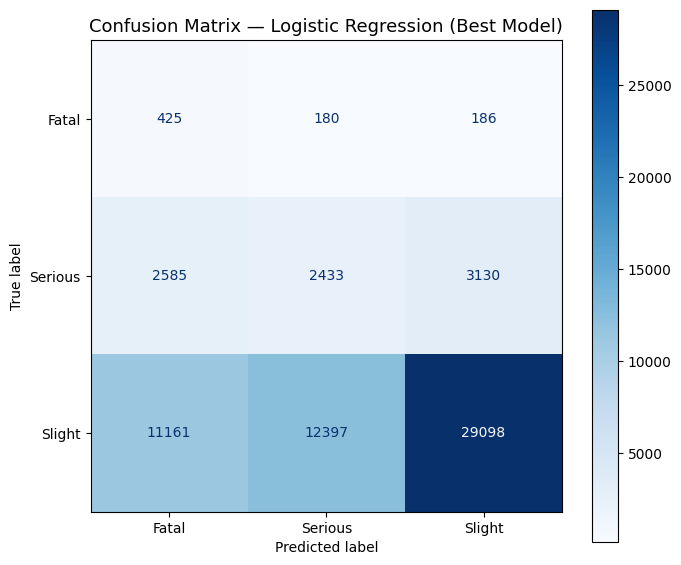


Confusion Matrix (row-normalised — shows recall per class):
[[0.537 0.228 0.235]
 [0.317 0.299 0.384]
 [0.212 0.235 0.553]]


In [18]:
# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
# Shows exactly where the model is correct and where it makes mistakes
#
# How to read it:
#   Rows    = ACTUAL class (what the accident really was)
#   Columns = PREDICTED class (what the model guessed)
#   Diagonal (top-left → bottom-right) = correct predictions ✅
#   Off-diagonal = wrong predictions ❌
#
# Most dangerous error: predicting "Slight" when accident was actually "Fatal"
# → look at row=Fatal, col=Slight — this number should be as low as possible

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Build confusion matrix using best_lr predictions (y_best_pred from Cell 21)
cm = confusion_matrix(y_test, y_best_pred, labels=best_lr.classes_)

fig, ax = plt.subplots(figsize=(7, 6))

# Display as a colour heatmap — darker blue = more predictions in that cell
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_lr.classes_   # shows actual class labels (Fatal/Serious/Slight)
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title("Confusion Matrix — Logistic Regression (Best Model)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Also print row-normalised version ────────────────────────────────────────
# Row-normalised: shows what % of each actual class was predicted correctly
# e.g. 0.72 in Fatal row, Fatal col = model correctly identified 72% of Fatal accidents
import numpy as np
cm_norm = (cm.T / cm.sum(axis=1, where=cm.sum(axis=1) != 0)).T
print("\nConfusion Matrix (row-normalised — shows recall per class):")
print(np.round(cm_norm, 3))

# **ROC Curves (One-vs-Rest per class)**

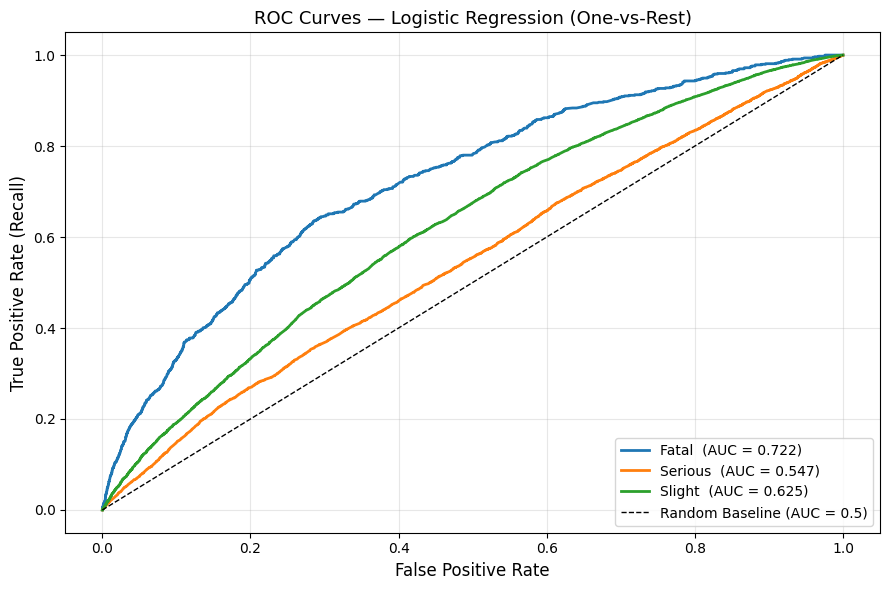


Overall ROC-AUC (OvR weighted): 0.6156


In [19]:
# ── ROC CURVES (ONE-VS-REST) ──────────────────────────────────────────────────
# ROC = Receiver Operating Characteristic
# For each class we ask: how well can the model separate THIS class from the rest?
#
# X-axis = False Positive Rate (how often we wrongly predict this class)
# Y-axis = True Positive Rate  (how often we correctly find this class)
#
# Perfect model → curve hugs top-left corner → AUC = 1.0
# Random model  → follows the diagonal       → AUC = 0.5
# We plot one curve per severity class (Fatal / Serious / Slight)

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get probability scores for each class from the best model
# y_prob shape = (n_test_rows, 3) — one probability column per class
y_prob = best_lr.predict_proba(Xte_lr_dense)

# label_binarize converts labels to binary format for one-vs-rest calculation
# e.g. for Fatal: [1, 0, 0, 1, ...] — 1 if Fatal, 0 for everything else
classes    = best_lr.classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(9, 6))

# Plot one ROC curve per class
for i, cls in enumerate(classes):
    # fpr = false positive rate at each decision threshold
    # tpr = true positive rate at each decision threshold
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_val  = auc(fpr, tpr)   # area under this class's curve
    plt.plot(fpr, tpr, linewidth=2, label=f'{cls}  (AUC = {roc_auc_val:.3f})')

# Diagonal = what a completely random classifier would achieve (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline (AUC = 0.5)')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curves — Logistic Regression (One-vs-Rest)", fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the overall weighted ROC-AUC (single number for the report)
overall_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
print(f"\nOverall ROC-AUC (OvR weighted): {overall_auc:.4f}")

# **Feature Importance (Top 20 Coefficients)**

/tmp/ipykernel_395/651486025.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=coef_df, palette='viridis')


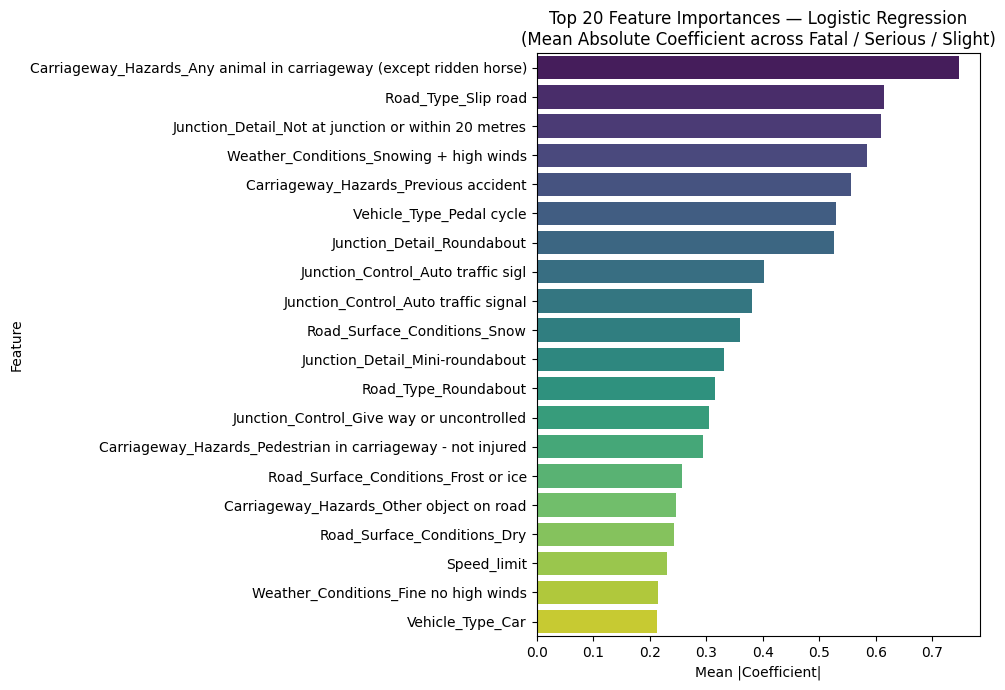

Top 10 most influential features:
                                                            Feature  Importance
Carriageway_Hazards_Any animal in carriageway (except ridden horse)    0.746853
                                                Road_Type_Slip road    0.613791
                Junction_Detail_Not at junction or within 20 metres    0.609324
                            Weather_Conditions_Snowing + high winds    0.584755
                              Carriageway_Hazards_Previous accident    0.556304
                                           Vehicle_Type_Pedal cycle    0.529590
                                         Junction_Detail_Roundabout    0.526566
                                 Junction_Control_Auto traffic sigl    0.402417
                               Junction_Control_Auto traffic signal    0.381558
                                       Road_Surface_Conditions_Snow    0.359675


In [20]:
# ── TOP 20 FEATURE IMPORTANCES ────────────────────────────────────────────────
# Logistic Regression assigns a coefficient to every feature
# The coefficient tells us HOW MUCH and in WHICH DIRECTION each feature
# pushes the model toward a particular severity class
#
# We take mean absolute coefficient across all 3 classes (Fatal/Serious/Slight)
# to get ONE importance score per feature
# Larger absolute value = stronger influence on the prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Step 1: Get feature names after one-hot encoding ──────────────────────────
# preproc_lr.named_transformers_['cat'] accesses the categorical pipeline
# .get_feature_names_out() returns names like "Weather_Conditions_Fine_no_high"
cat_feature_names = (
    preproc_lr
    .named_transformers_['cat']['onehot']
    .get_feature_names_out(cat_cols)
    .tolist()
)

# Full list = all OHE column names + original numeric column names
all_feature_names = cat_feature_names + num_cols

# ── Step 2: Compute mean absolute coefficient across all 3 classes ────────────
# best_lr.coef_ shape = (3 classes, n_features)
# np.abs() removes sign — we only care about strength, not direction
# np.mean(axis=0) averages across the 3 class rows → one score per feature
mean_abs_coef = np.mean(np.abs(best_lr.coef_), axis=0)

# ── Step 3: Build sorted DataFrame, keep top 20 ───────────────────────────────
coef_df = (
    pd.DataFrame({
        'Feature':    all_feature_names[:len(mean_abs_coef)],
        'Importance': mean_abs_coef
    })
    .sort_values('Importance', ascending=False)
    .head(20)   # only show the 20 most influential features
)

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=coef_df, palette='viridis')
plt.title("Top 20 Feature Importances — Logistic Regression\n(Mean Absolute Coefficient across Fatal / Serious / Slight)")
plt.xlabel("Mean |Coefficient|")
plt.tight_layout()
plt.show()

# Print top 10 for the report
print("Top 10 most influential features:")
print(coef_df.head(10).to_string(index=False))

# **Final Results Summary Table**

In [21]:
# ── FINAL RESULTS SUMMARY TABLE ───────────────────────────────────────────────
# Collect ALL key metrics in one clean table
# This exact table goes into your group report under "Results"
# Your teammates should produce the same table for their algorithms
# so the report can compare all 4 models side by side

from sklearn.metrics import (
    f1_score, recall_score,
    balanced_accuracy_score, roc_auc_score
)
import pandas as pd

# All metrics calculated using best_lr predictions on the test set
results_df = pd.DataFrame({
    'Metric': [
        'Training Accuracy',        # how well model fits training data
        'Test Accuracy',            # real-world performance on unseen data
        'Macro F1-Score',           # F1 treating all 3 classes equally (best for imbalanced)
        'Weighted F1-Score',        # F1 weighted by class size
        'Macro Recall',             # average recall across Fatal / Serious / Slight
        'Balanced Accuracy',        # accuracy adjusted for class imbalance
        'ROC-AUC (OvR weighted)'    # how well model separates classes
    ],
    'Score': [
        # Training accuracy — from Cell 19
        round(accuracy_score(ytr_lr_bal,
              best_lr.predict(Xtr_lr_bal)),                              4),
        # Test accuracy
        round(accuracy_score(y_test, y_best_pred),                       4),
        # Macro F1
        round(f1_score(y_test, y_best_pred, average='macro'),            4),
        # Weighted F1
        round(f1_score(y_test, y_best_pred, average='weighted'),         4),
        # Macro Recall
        round(recall_score(y_test, y_best_pred, average='macro'),        4),
        # Balanced Accuracy
        round(balanced_accuracy_score(y_test, y_best_pred),              4),
        # ROC-AUC
        round(roc_auc_score(y_test, y_prob,
              multi_class='ovr', average='weighted'),                    4)
    ]
})

print("=" * 50)
print("   LOGISTIC REGRESSION — FINAL RESULTS")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)
print(f"\nBest Hyperparameters : {grid_search.best_params_}")
print(f"GridSearchCV CV F1   : {grid_search.best_score_:.4f}")

   LOGISTIC REGRESSION — FINAL RESULTS
                Metric  Score
     Training Accuracy 0.4835
         Test Accuracy 0.5188
        Macro F1-Score 0.3170
     Weighted F1-Score 0.6133
          Macro Recall 0.4628
     Balanced Accuracy 0.4628
ROC-AUC (OvR weighted) 0.6156

Best Hyperparameters : {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
GridSearchCV CV F1   : 0.4734


# **Save Model to Artifacts**

In [22]:
# ── SAVE MODEL & METADATA ─────────────────────────────────────────────────────
import os, joblib, json
import numpy as np

# Create artifacts/ folder if it doesn't already exist
os.makedirs('artifacts', exist_ok=True)

# Save the best Logistic Regression model as a .pkl file
# To reload later: model = joblib.load('artifacts/logistic_regression_model.pkl')
joblib.dump(best_lr, 'artifacts/logistic_regression_model.pkl')
print("✅ Model saved  → artifacts/logistic_regression_model.pkl")

# ── FIX: custom JSON encoder that converts ALL numpy types to plain Python ──
# json.dump crashes on numpy int64/float32 etc. because JSON only knows
# plain Python int and float — this encoder converts them automatically
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):   # covers int8, int16, int32, int64
            return int(obj)
        if isinstance(obj, np.floating):  # covers float16, float32, float64
            return float(obj)
        if isinstance(obj, np.ndarray):   # converts numpy arrays to plain lists
            return obj.tolist()
        return super().default(obj)       # fall back to default for everything else

# ── Also convert best_params_ values individually just to be safe ──
# grid_search.best_params_ can contain numpy int64/float64 values
safe_params = {k: (int(v) if isinstance(v, np.integer)
                   else float(v) if isinstance(v, np.floating)
                   else v)
               for k, v in grid_search.best_params_.items()}

# Build metadata dictionary
meta = {
    'best_params':   safe_params,                                    # winning hyperparameters
    'classes':       [str(c) for c in best_lr.classes_],            # Fatal / Serious / Slight as strings
    'n_features':    int(Xtr_lr_bal.shape[1]),                       # plain Python int (not numpy)
    'cv_f1_macro':   round(float(grid_search.best_score_), 4),       # plain Python float
    'test_macro_f1': round(float(f1_score(y_test,
                     y_best_pred, average='macro')), 4),             # plain Python float
}

# Save using the NumpyEncoder — handles any remaining numpy types automatically
with open('artifacts/logistic_regression_meta.json', 'w') as f:
    json.dump(meta, f, indent=2, cls=NumpyEncoder)

print("✅ Metadata saved → artifacts/logistic_regression_meta.json")
print("\nSaved metadata:")
print(json.dumps(meta, indent=2, cls=NumpyEncoder))

✅ Model saved  → artifacts/logistic_regression_model.pkl
✅ Metadata saved → artifacts/logistic_regression_meta.json

Saved metadata:
{
  "best_params": {
    "C": 0.1,
    "penalty": "l2",
    "solver": "saga"
  },
  "classes": [
    "Fatal",
    "Serious",
    "Slight"
  ],
  "n_features": 72,
  "cv_f1_macro": 0.4734,
  "test_macro_f1": 0.317
}
